# Series Temporales Basicas: Rotacion de Inventario Trimestral de LMB

## 1. Contexto

El area de operaciones de LMB mide, cada trimestre, cuantas veces "rota" el inventario de la bodega (cuantas veces se vende y repone el stock completo) durante **3 anios (12 trimestres: Q1-Q4 x Anio 1-3)**.

El objetivo es aplicar los conceptos basicos de series temporales sobre este conjunto para responder: **la eficiencia de la bodega, esta mejorando, empeorando, o simplemente varia por temporada?**

- **Tendencia (T):** direccion general de la rotacion a lo largo de los 12 trimestres.
- **Estacionalidad (E):** el patron repetido segun el trimestre del anio (Q1..Q4).
- **Ciclo (C):** con solo 3 anios de datos no es posible aislar un componente ciclico (se necesitarian varios anios para detectar subidas/bajadas de mediano plazo no periodicas).
- **Ruido/Irregularidad (I):** variacion que no explican los componentes anteriores.

Ademas se calcula la **variacion % entre periodos** para medir el cambio en terminos relativos, y se revisa si el pico de Q4 debe tratarse como **estacionalidad** o como **outlier**.

## 2. Modelo aditivo simplificado

$$\text{Valor observado} = \text{Tendencia} + \text{Estacionalidad} + \text{Ciclo} + \text{Ruido}$$

$$\text{Variacion \%} = \frac{\text{Valor actual} - \text{Valor anterior}}{\text{Valor anterior}} \times 100$$

$$\hat{Y} = a + bX \quad (\text{Recta de regresion})$$

Donde: **X = Trimestre (periodo)**, **Y = Rotacion de inventario**, **a** = intercepto, **b** = pendiente, **Ŷ** = valor predicho por la recta.

## 3. Datos del caso: Rotacion de inventario por trimestre

| Trimestre | Anio 1 | Anio 2 | Anio 3 |
|---|---|---|---|
| Q1 | 2.1 | 2.3 | 2.6 |
| Q2 | 2.4 | 2.6 | 2.9 |
| Q3 | 2.6 | 2.8 | 3.1 |
| Q4 | 3.2 | 3.5 | 3.9 |

## 4. Desarrollo en Python

### 4.1 Carga de datos y construccion de la tabla

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paso 1: Datos del ejercicio
periodo = list(range(1, 13))
ano = [1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3]
trimestre = ["Q1", "Q2", "Q3", "Q4"] * 3
rotacion = [2.1, 2.4, 2.6, 3.2,
            2.3, 2.6, 2.8, 3.5,
            2.6, 2.9, 3.1, 3.9]
etiqueta = [f"{t} (Año {a})" for t, a in zip(trimestre, ano)]

df = pd.DataFrame({
    "Periodo": periodo,
    "Año": ano,
    "Trimestre": trimestre,
    "Etiqueta": etiqueta,
    "Rotacion": rotacion,
})
df

,Periodo,Año,Trimestre,Etiqueta,Rotacion
0,1,1,Q1,Q1 (Año 1),2.1
1,2,1,Q2,Q2 (Año 1),2.4
2,3,1,Q3,Q3 (Año 1),2.6
3,4,1,Q4,Q4 (Año 1),3.2
4,5,2,Q1,Q1 (Año 2),2.3
5,6,2,Q2,Q2 (Año 2),2.6
6,7,2,Q3,Q3 (Año 2),2.8
7,8,2,Q4,Q4 (Año 2),3.5
8,9,3,Q1,Q1 (Año 3),2.6
9,10,3,Q2,Q2 (Año 3),2.9


### 4.2 Variacion % entre periodos consecutivos

In [2]:
# Paso 2: Variacion % respecto al periodo anterior
df["Variacion_%"] = (df["Rotacion"] - df["Rotacion"].shift(1)) / df["Rotacion"].shift(1) * 100
df[["Periodo", "Etiqueta", "Rotacion", "Variacion_%"]].round(2)

,Periodo,Etiqueta,Rotacion,Variacion_%
0,1,Q1 (Año 1),2.1,NaN
1,2,Q2 (Año 1),2.4,14.29
2,3,Q3 (Año 1),2.6,8.33
3,4,Q4 (Año 1),3.2,23.08
4,5,Q1 (Año 2),2.3,-28.13
5,6,Q2 (Año 2),2.6,13.04
6,7,Q3 (Año 2),2.8,7.69
7,8,Q4 (Año 2),3.5,25.00
8,9,Q1 (Año 3),2.6,-25.71
9,10,Q2 (Año 3),2.9,11.54


### 4.3 Tabla de minimos cuadrados (calculo manual de a y b)

Antes de usar `np.polyfit`, se puede calcular la recta de regresion $\hat{Y} = a + bX$ a mano, con la tabla clasica de minimos cuadrados:

$$b = \frac{n\sum XY - \sum X \sum Y}{n\sum X^2 - (\sum X)^2} \qquad a = \frac{\sum Y - b\sum X}{n}$$

Donde $n$ es la cantidad de datos, y se necesitan las columnas $X$, $Y$, $X^2$ y $XY$.

In [3]:
# Tabla de minimos cuadrados: X, Y, X2, XY
tabla = df[["Periodo", "Rotacion"]].copy()
tabla.columns = ["X", "Y"]
tabla["X2"] = tabla["X"] ** 2
tabla["XY"] = tabla["X"] * tabla["Y"]

# Fila de sumatorias (Sigma)
sumatorias = tabla.sum(numeric_only=True)
sumatorias.name = "Suma"
tabla_con_sumas = pd.concat([tabla, sumatorias.to_frame().T])
tabla_con_sumas

,X,Y,X2,XY
0,1.0,2.1,1.0,2.1
1,2.0,2.4,4.0,4.8
2,3.0,2.6,9.0,7.8
3,4.0,3.2,16.0,12.8
4,5.0,2.3,25.0,11.5
5,6.0,2.6,36.0,15.6
6,7.0,2.8,49.0,19.6
7,8.0,3.5,64.0,28.0
8,9.0,2.6,81.0,23.4
9,10.0,2.9,100.0,29.0


In [4]:
# Calculo manual de a y b a partir de las sumatorias
n = len(df)
suma_X, suma_Y = tabla["X"].sum(), tabla["Y"].sum()
suma_X2, suma_XY = tabla["X2"].sum(), tabla["XY"].sum()

b_manual = (n * suma_XY - suma_X * suma_Y) / (n * suma_X2 - suma_X ** 2)
a_manual = (suma_Y - b_manual * suma_X) / n

print(f"n = {n}")
print(f"SumaX = {suma_X}, SumaY = {suma_Y:.2f}, SumaX2 = {suma_X2}, SumaXY = {suma_XY:.2f}")
print(f"\nb (pendiente) = {b_manual:.4f}")
print(f"a (intercepto) = {a_manual:.4f}")
print(f"\nRecta de regresion: Y_hat = {a_manual:.3f} + {b_manual:.3f}X")
print("\n(Estos valores deben coincidir con los que da np.polyfit en el siguiente paso)")

n = 12
SumaX = 78, SumaY = 34.00, SumaX2 = 650, SumaXY = 235.50

b (pendiente) = 0.1014
a (intercepto) = 2.1742

Recta de regresion: Y_hat = 2.174 + 0.101X

(Estos valores deben coincidir con los que da np.polyfit en el siguiente paso)


### 4.4 Estimacion de la Tendencia (regresion lineal simple: Rotacion ~ Periodo)

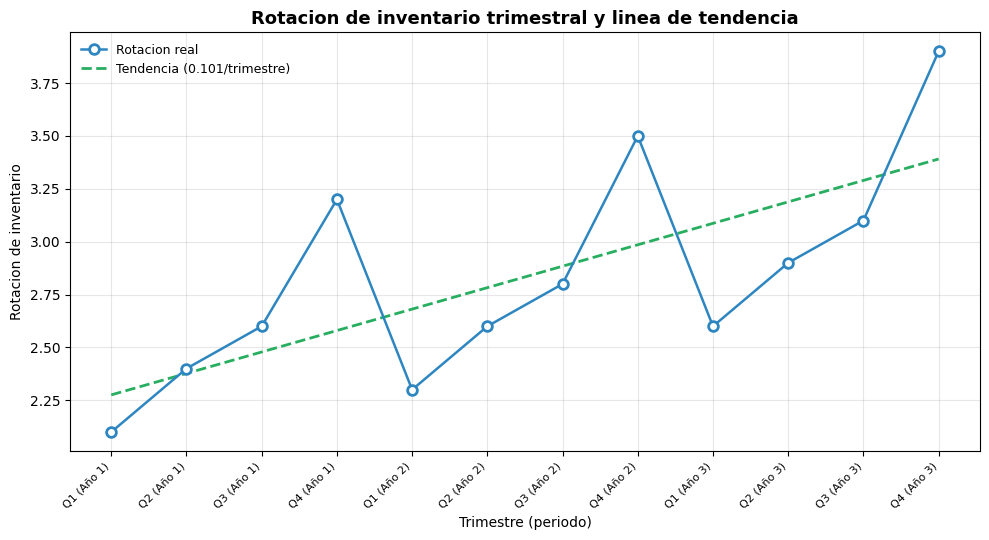

Tendencia estimada: Rotacion ~= 0.101 x Periodo + 2.174
Cambio promedio estimado: 0.101 veces de rotacion por trimestre


In [5]:
# Paso 3: Tendencia mediante ajuste lineal
pendiente, intercepto = np.polyfit(df["Periodo"], df["Rotacion"], 1)
df["Tendencia"] = pendiente * df["Periodo"] + intercepto

plt.figure(figsize=(10, 5.5))
plt.plot(df["Periodo"], df["Rotacion"], marker="o", color="#2E86C1", markersize=7,
         markerfacecolor="white", markeredgewidth=2, linewidth=1.8, label="Rotacion real", zorder=3)
plt.plot(df["Periodo"], df["Tendencia"], color="#27AE60", linewidth=2, linestyle="--",
         label=f"Tendencia ({pendiente:.3f}/trimestre)")

plt.title("Rotacion de inventario trimestral y linea de tendencia", fontsize=13, fontweight="bold")
plt.xlabel("Trimestre (periodo)")
plt.ylabel("Rotacion de inventario")
plt.xticks(df["Periodo"], df["Etiqueta"], rotation=45, ha="right", fontsize=8)
plt.grid(alpha=0.3)
plt.legend(loc="upper left", fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

print(f"Tendencia estimada: Rotacion ~= {pendiente:.3f} x Periodo + {intercepto:.3f}")
print(f"Cambio promedio estimado: {pendiente:.3f} veces de rotacion por trimestre")

### 4.5 Fuerza de la relacion: coeficiente de correlacion de Pearson

$$r = \frac{n\sum XY - \sum X \sum Y}{\sqrt{[n\sum X^2 - (\sum X)^2][n\sum Y^2 - (\sum Y)^2]}}$$

Complementa a la recta de regresion: mide que tan fuerte y lineal es la relacion entre Periodo (X) y Rotacion (Y). Reutiliza las sumatorias ya calculadas en la tabla de minimos cuadrados (Sigma X, Sigma Y, Sigma XY, Sigma X2), agregando Sigma Y2.

In [6]:
# Calculo manual de r, reutilizando las sumatorias de la tabla de minimos cuadrados
suma_Y2 = (tabla["Y"] ** 2).sum()

numerador_r = n * suma_XY - suma_X * suma_Y
denominador_r = np.sqrt((n * suma_X2 - suma_X ** 2) * (n * suma_Y2 - suma_Y ** 2))
r_manual = numerador_r / denominador_r

# Verificacion con librerias
r_pandas = df["Periodo"].corr(df["Rotacion"])
r_numpy = np.corrcoef(df["Periodo"], df["Rotacion"])[0, 1]

print(f"SumaY2 = {suma_Y2:.2f}")
print(f"r (calculo manual) = {r_manual:.4f}")
print(f"r (pandas)          = {r_pandas:.4f}")
print(f"r (numpy)            = {r_numpy:.4f}")

if r_manual >= 0.7:
    interpretacion = "correlacion positiva fuerte"
elif r_manual >= 0.3:
    interpretacion = "correlacion positiva moderada"
elif r_manual >= 0.01:
    interpretacion = "correlacion positiva debil"
else:
    interpretacion = "sin correlacion lineal relevante"

print(f"\nInterpretacion: {interpretacion} entre Periodo y Rotacion (r = {r_manual:.3f})")

SumaY2 = 99.30
r (calculo manual) = 0.7040
r (pandas)          = 0.7040
r (numpy)            = 0.7040

Interpretacion: correlacion positiva fuerte entre Periodo y Rotacion (r = 0.704)


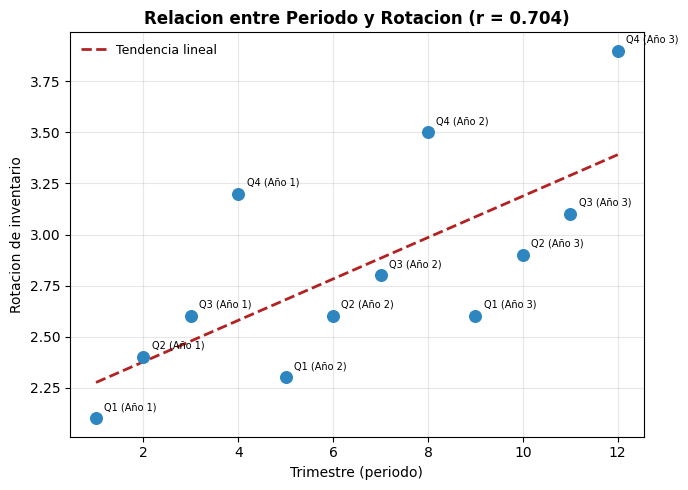

In [7]:
# Dispersion Periodo vs. Rotacion con la recta de tendencia, mostrando el valor de r en el titulo
plt.figure(figsize=(7, 5))
plt.scatter(df["Periodo"], df["Rotacion"], color="#2E86C1", s=70, zorder=3)
plt.plot(df["Periodo"], df["Tendencia"], color="firebrick", linestyle="--", linewidth=2, label="Tendencia lineal")

for _, row in df.iterrows():
    plt.annotate(row["Etiqueta"], (row["Periodo"], row["Rotacion"]), textcoords="offset points",
                 xytext=(6, 6), fontsize=7)

plt.title(f"Relacion entre Periodo y Rotacion (r = {r_manual:.3f})", fontsize=12, fontweight="bold")
plt.xlabel("Trimestre (periodo)")
plt.ylabel("Rotacion de inventario")
plt.legend(fontsize=9, frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.6 Estimacion de la Estacionalidad (residuo respecto a la tendencia)

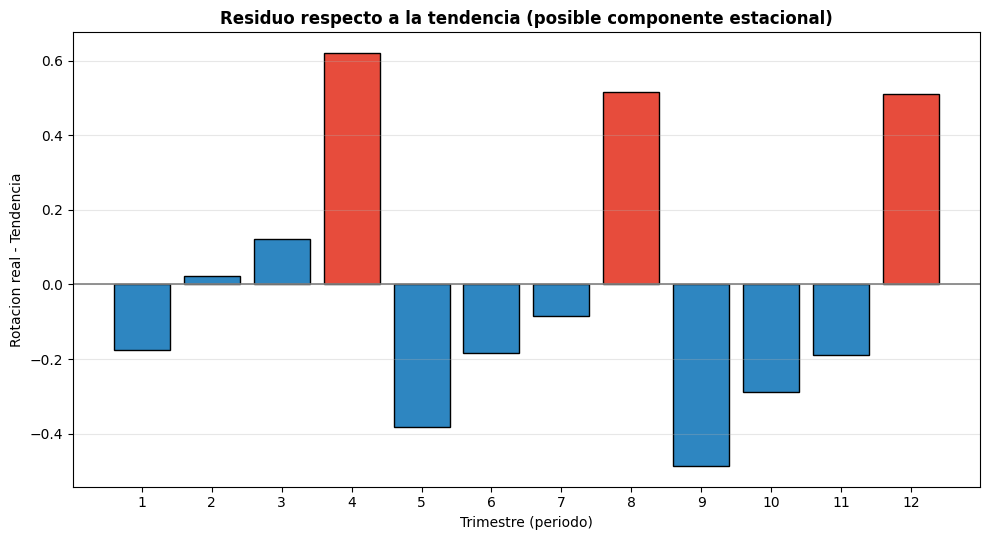

Residuo en Q4 de cada anio (posible temporada alta):
    Periodo    Etiqueta  Rotacion  Tendencia  Residuo_vs_tendencia
3         4  Q4 (Año 1)       3.2      2.580                 0.620
7         8  Q4 (Año 2)       3.5      2.985                 0.515
11       12  Q4 (Año 3)       3.9      3.391                 0.509


In [8]:
# Paso 4: Residuo = Rotacion real - Tendencia (lo que la tendencia no explica)
df["Residuo_vs_tendencia"] = df["Rotacion"] - df["Tendencia"]

es_Q4 = df["Trimestre"] == "Q4"
colores = np.where(es_Q4, "#E74C3C", "#2E86C1")

plt.figure(figsize=(10, 5.5))
plt.bar(df["Periodo"].astype(str), df["Residuo_vs_tendencia"], color=colores, edgecolor="black")
plt.axhline(0, color="gray", linewidth=1.2)
plt.title("Residuo respecto a la tendencia (posible componente estacional)", fontsize=12, fontweight="bold")
plt.xlabel("Trimestre (periodo)")
plt.ylabel("Rotacion real - Tendencia")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("Residuo en Q4 de cada anio (posible temporada alta):")
print(df.loc[es_Q4, ["Periodo", "Etiqueta", "Rotacion", "Tendencia", "Residuo_vs_tendencia"]].round(3))

In [9]:
# Indice estacional promedio por tipo de trimestre (Q1..Q4), usando el residuo
indice_estacional = df.groupby("Trimestre")["Residuo_vs_tendencia"].mean().round(3)
indice_estacional

Trimestre
Q1   -0.348
Q2   -0.149
Q3   -0.051
Q4    0.548
Name: Residuo_vs_tendencia, dtype: float64

### 4.7 Variacion % interanual por trimestre (mismo trimestre, distintos anios)

In [10]:
# Paso 5: Comparar cada trimestre entre el Anio 1, Anio 2 y Anio 3
for trim in ["Q1", "Q2", "Q3", "Q4"]:
    valores = df.loc[df["Trimestre"] == trim, "Rotacion"].values
    var_1_2 = (valores[1] - valores[0]) / valores[0] * 100
    var_2_3 = (valores[2] - valores[1]) / valores[1] * 100
    print(f"{trim}: Anio1={valores[0]}, Anio2={valores[1]}, Anio3={valores[2]}  "
          f"->  var Anio1->2 = {var_1_2:.1f}%,  var Anio2->3 = {var_2_3:.1f}%")

Q1: Anio1=2.1, Anio2=2.3, Anio3=2.6  ->  var Anio1->2 = 9.5%,  var Anio2->3 = 13.0%
Q2: Anio1=2.4, Anio2=2.6, Anio3=2.9  ->  var Anio1->2 = 8.3%,  var Anio2->3 = 11.5%
Q3: Anio1=2.6, Anio2=2.8, Anio3=3.1  ->  var Anio1->2 = 7.7%,  var Anio2->3 = 10.7%
Q4: Anio1=3.2, Anio2=3.5, Anio3=3.9  ->  var Anio1->2 = 9.4%,  var Anio2->3 = 11.4%


### 4.8 Estacionalidad o valores atipicos? — comparacion de metodos (z-score, RIC/boxplot, grafico de control)

In [11]:
# Paso 6: Verificar si el pico de Q4 es atipico o un patron estacional esperado
media_res = df["Residuo_vs_tendencia"].mean()
desv_res = df["Residuo_vs_tendencia"].std(ddof=0)
df["z_score_residuo"] = (df["Residuo_vs_tendencia"] - media_res) / desv_res

print(df[["Periodo", "Etiqueta", "Residuo_vs_tendencia", "z_score_residuo"]].round(2))

atipicos = df[df["z_score_residuo"].abs() > 3]
print("\n¿Valores con |z| > 3 (posibles atipicos reales)?")
if atipicos.empty:
    print("Ninguno. El pico de Q4 se repite cada anio de forma consistente -> es estacionalidad, no un outlier aislado.")
else:
    print(atipicos[["Periodo", "Etiqueta", "Rotacion"]])

    Periodo    Etiqueta  Residuo_vs_tendencia  z_score_residuo
0         1  Q1 (Año 1)                 -0.18            -0.50
1         2  Q2 (Año 1)                  0.02             0.07
2         3  Q3 (Año 1)                  0.12             0.34
3         4  Q4 (Año 1)                  0.62             1.76
4         5  Q1 (Año 2)                 -0.38            -1.08
5         6  Q2 (Año 2)                 -0.18            -0.52
6         7  Q3 (Año 2)                 -0.08            -0.24
7         8  Q4 (Año 2)                  0.51             1.46
8         9  Q1 (Año 3)                 -0.49            -1.38
9        10  Q2 (Año 3)                 -0.29            -0.82
10       11  Q3 (Año 3)                 -0.19            -0.54
11       12  Q4 (Año 3)                  0.51             1.44

¿Valores con |z| > 3 (posibles atipicos reales)?
Ninguno. El pico de Q4 se repite cada anio de forma consistente -> es estacionalidad, no un outlier aislado.


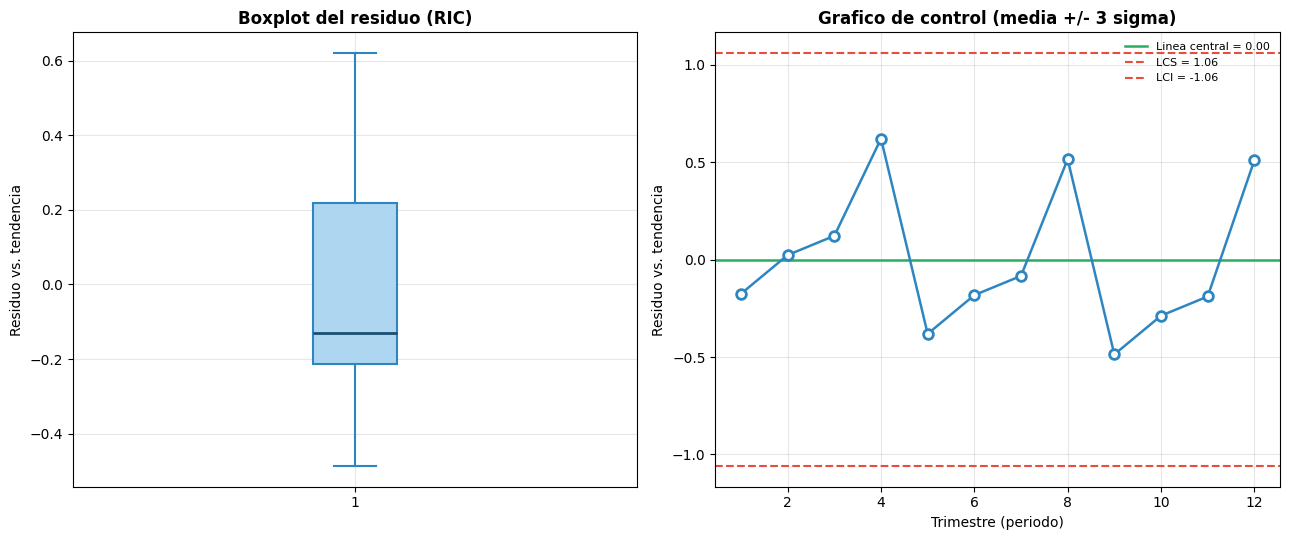


RIC: Q1=-0.214, Q3=0.218, RIC=0.433, limites=(-0.863, 0.867)
Atipicos por RIC: ninguno
Atipicos por grafico de control (3 sigma): ninguno


In [12]:
# Refuerzo del diagnostico: RIC/boxplot y grafico de control, aplicados sobre el residuo (Rotacion - Tendencia)

# --- Metodo RIC ---
Q1 = np.quantile(df["Residuo_vs_tendencia"], 0.25, method="linear")
Q3 = np.quantile(df["Residuo_vs_tendencia"], 0.75, method="linear")
RIC = Q3 - Q1
limite_inferior = Q1 - 1.5 * RIC
limite_superior = Q3 + 1.5 * RIC
outliers_ric = df[(df["Residuo_vs_tendencia"] < limite_inferior) | (df["Residuo_vs_tendencia"] > limite_superior)]

# --- Grafico de control (media +/- 3 desviaciones estandar) ---
LC = df["Residuo_vs_tendencia"].mean()
LCS = LC + 3 * desv_res
LCI = LC - 3 * desv_res
fuera_control = df[(df["Residuo_vs_tendencia"] > LCS) | (df["Residuo_vs_tendencia"] < LCI)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].boxplot(
    df["Residuo_vs_tendencia"], vert=True, patch_artist=True,
    boxprops=dict(facecolor="#AED6F1", color="#2E86C1", linewidth=1.5),
    medianprops=dict(color="#1B4F72", linewidth=2),
    whiskerprops=dict(color="#2E86C1", linewidth=1.5),
    capprops=dict(color="#2E86C1", linewidth=1.5),
    flierprops=dict(marker="o", markerfacecolor="#E74C3C", markeredgecolor="#C0392B", markersize=8)
)
axes[0].set_title("Boxplot del residuo (RIC)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Residuo vs. tendencia")
axes[0].grid(alpha=0.3)
for _, row in outliers_ric.iterrows():
    axes[0].annotate(f"{row['Etiqueta']}: {row['Residuo_vs_tendencia']:.2f}",
                      (1, row["Residuo_vs_tendencia"]), textcoords="offset points",
                      xytext=(15, 0), fontsize=9, color="#C0392B", fontweight="bold")

axes[1].plot(df["Periodo"], df["Residuo_vs_tendencia"], marker="o", color="#2E86C1",
             markersize=7, markerfacecolor="white", markeredgewidth=2, linewidth=1.8, zorder=3)
axes[1].axhline(LC, color="#27AE60", linewidth=1.8, label=f"Linea central = {LC:.2f}")
axes[1].axhline(LCS, color="#E74C3C", linestyle="--", linewidth=1.5, label=f"LCS = {LCS:.2f}")
axes[1].axhline(LCI, color="#E74C3C", linestyle="--", linewidth=1.5, label=f"LCI = {LCI:.2f}")
axes[1].set_title("Grafico de control (media +/- 3 sigma)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Trimestre (periodo)")
axes[1].set_ylabel("Residuo vs. tendencia")
axes[1].legend(fontsize=8, frameon=False)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nRIC: Q1={Q1:.3f}, Q3={Q3:.3f}, RIC={RIC:.3f}, limites=({limite_inferior:.3f}, {limite_superior:.3f})")
print(f"Atipicos por RIC: {'ninguno' if outliers_ric.empty else outliers_ric['Etiqueta'].tolist()}")
print(f"Atipicos por grafico de control (3 sigma): {'ninguno' if fuera_control.empty else fuera_control['Etiqueta'].tolist()}")

### 4.9 Modelo aditivo simplificado — reconstruccion de componentes

In [13]:
# Paso 7: Rotacion = Tendencia + Estacionalidad + Ruido
# (no se calcula Ciclo: se necesitan varios anios de datos para aislarlo)
df["Estacionalidad_aprox"] = df["Trimestre"].map(indice_estacional)
df["Ruido"] = df["Residuo_vs_tendencia"] - df["Estacionalidad_aprox"]

resumen = df[["Periodo", "Etiqueta", "Rotacion", "Tendencia", "Estacionalidad_aprox", "Ruido"]].round(3)
resumen

,Periodo,Etiqueta,Rotacion,Tendencia,Estacionalidad_aprox,Ruido
0,1,Q1 (Año 1),2.1,2.276,-0.348,0.172
1,2,Q2 (Año 1),2.4,2.377,-0.149,0.172
2,3,Q3 (Año 1),2.6,2.478,-0.051,0.173
3,4,Q4 (Año 1),3.2,2.580,0.548,0.072
4,5,Q1 (Año 2),2.3,2.681,-0.348,-0.033
5,6,Q2 (Año 2),2.6,2.783,-0.149,-0.034
6,7,Q3 (Año 2),2.8,2.884,-0.051,-0.033
7,8,Q4 (Año 2),3.5,2.985,0.548,-0.033
8,9,Q1 (Año 3),2.6,3.087,-0.348,-0.139
9,10,Q2 (Año 3),2.9,3.188,-0.149,-0.139


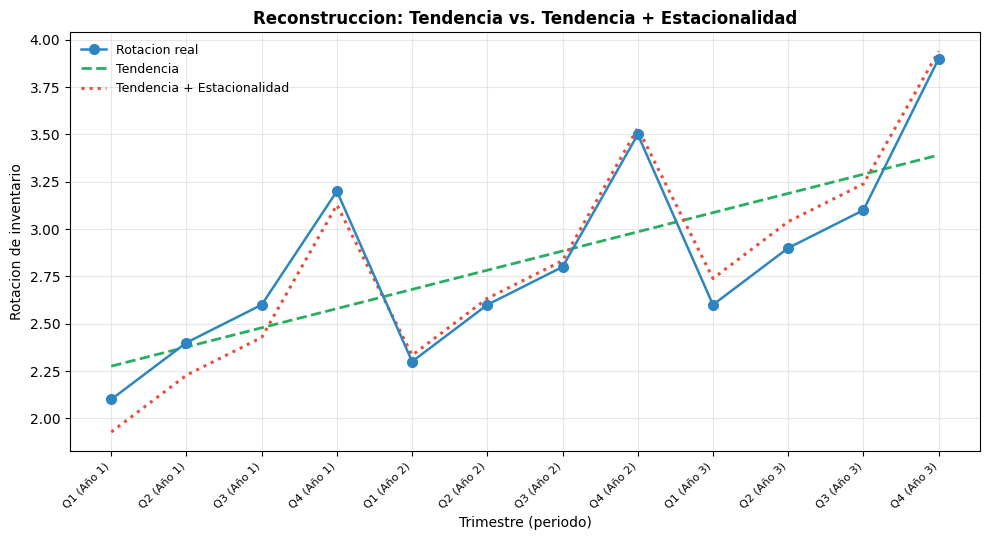

In [14]:
# Paso 8: Reconstruccion visual — Tendencia vs. Tendencia + Estacionalidad vs. Rotacion real
plt.figure(figsize=(10, 5.5))
plt.plot(df["Periodo"], df["Rotacion"], marker="o", color="#2E86C1", markersize=7,
         linewidth=1.8, label="Rotacion real", zorder=3)
plt.plot(df["Periodo"], df["Tendencia"], color="#27AE60", linestyle="--", linewidth=2, label="Tendencia")
plt.plot(df["Periodo"], df["Tendencia"] + df["Estacionalidad_aprox"], color="#E74C3C",
         linestyle=":", linewidth=2.2, label="Tendencia + Estacionalidad")

plt.title("Reconstruccion: Tendencia vs. Tendencia + Estacionalidad", fontsize=12, fontweight="bold")
plt.xlabel("Trimestre (periodo)")
plt.ylabel("Rotacion de inventario")
plt.xticks(df["Periodo"], df["Etiqueta"], rotation=45, ha="right", fontsize=8)
plt.grid(alpha=0.3)
plt.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

### 4.10 Vista alternativa: comparacion por trimestre entre anios

El mismo conjunto de datos se puede reorganizar en una tabla ancha (un trimestre por fila, una columna por anio) para comparar visualmente el comportamiento de cada anio dentro del mismo trimestre, en vez de ver los 12 periodos en una sola linea de tiempo. Se muestran tres vistas: **grafico de lineas** (una linea por anio, con la media de cada anio marcada en punteado horizontal), **grafico de barras agrupadas** (mismo criterio) y **grafico circular** con el peso relativo de la media de cada anio sobre el total.

Tabla ancha (Trimestre x Año):
           Año 1  Año 2  Año 3
Trimestre                     
Q1           2.1    2.3    2.6
Q2           2.4    2.6    2.9
Q3           2.6    2.8    3.1
Q4           3.2    3.5    3.9

Media de rotacion por año:
Año 1    2.575
Año 2    2.800
Año 3    3.125
dtype: float64


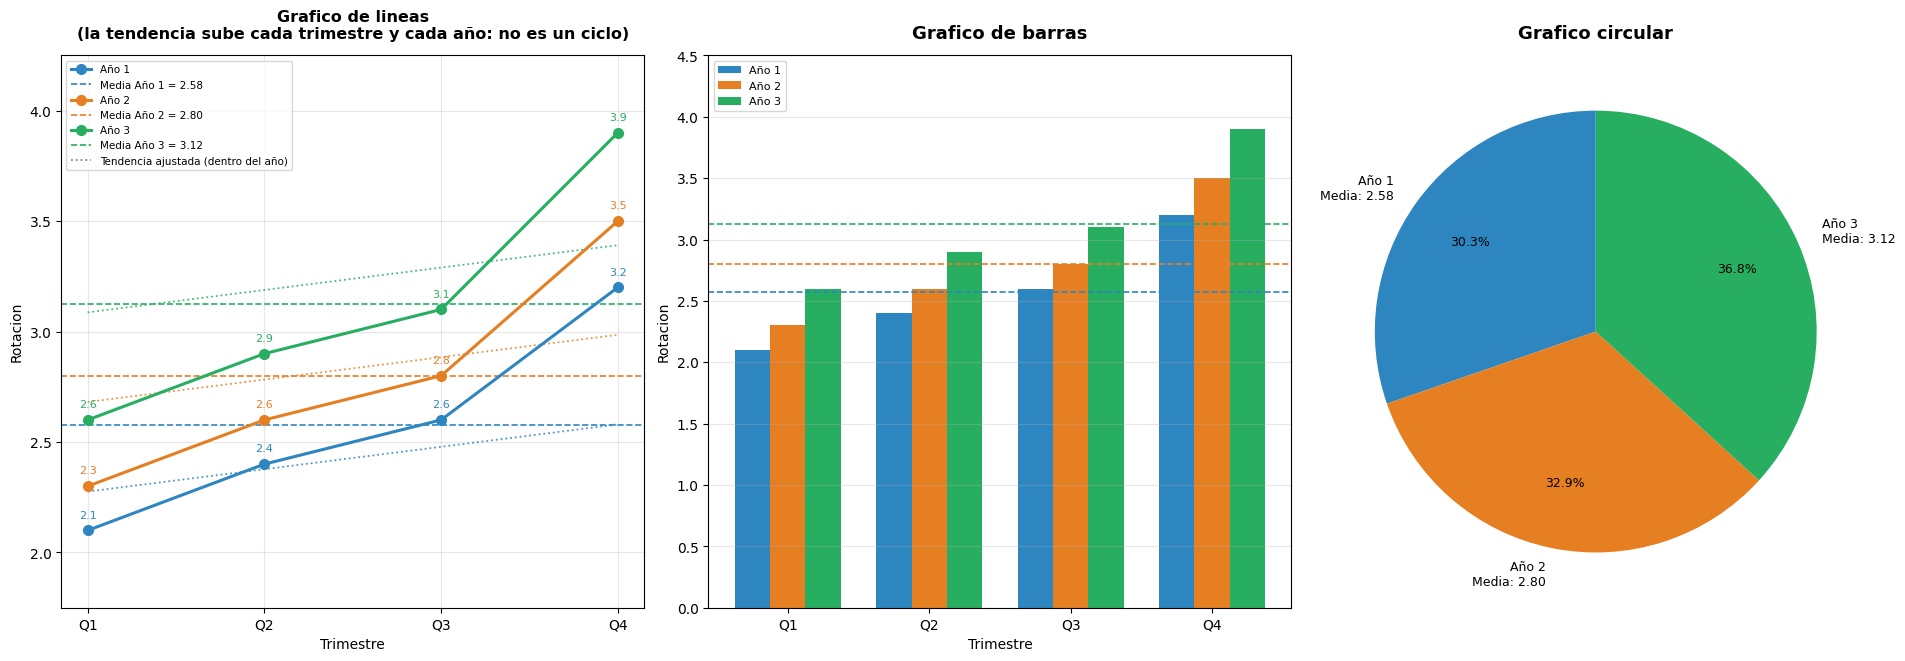


Nota: el zigzag de subida dentro de cada trimestre y el salto hacia arriba de un año al
siguiente (medias 2.58 -> 2.80 -> 3.12) son el mismo fenomeno: una TENDENCIA continua de
crecimiento. No hay ciclo (subidas y bajadas que se repiten sin crecer), porque cada año
cierra mas arriba que el anterior en los 4 trimestres.


In [15]:
# Tabla ancha: un trimestre por fila, un año por columna
tabla_ancha = df.pivot(index="Trimestre", columns="Año", values="Rotacion").loc[["Q1", "Q2", "Q3", "Q4"]]
tabla_ancha.columns = [f"Año {a}" for a in tabla_ancha.columns]
medias_anio = tabla_ancha.mean()

# Misma reorganizacion, pero con la Tendencia ajustada (seccion 4.4) en vez de la rotacion real:
# sirve para dejar claro que el movimiento de fondo es una TENDENCIA (crecimiento sostenido),
# no un CICLO (los "picos y valles" que se ven por trimestre son estacionalidad sobre esa tendencia).
tabla_tendencia = df.pivot(index="Trimestre", columns="Año", values="Tendencia").loc[["Q1", "Q2", "Q3", "Q4"]]
tabla_tendencia.columns = [f"Año {a}" for a in tabla_tendencia.columns]

print("Tabla ancha (Trimestre x Año):")
print(tabla_ancha)
print("\nMedia de rotacion por año:")
print(medias_anio.round(3))

colores_anio = {"Año 1": "#2E86C1", "Año 2": "#E67E22", "Año 3": "#27AE60"}

fig, axes = plt.subplots(1, 3, figsize=(19, 6.5), constrained_layout=True)

# --- Grafico de lineas: rotacion real (solido) + tendencia ajustada (punteado fino) por año ---
for col in tabla_ancha.columns:
    axes[0].plot(tabla_ancha.index, tabla_ancha[col], marker="o", markersize=7,
                 label=col, color=colores_anio[col], linewidth=2.2, zorder=3)
    for x_val, y_val in zip(tabla_ancha.index, tabla_ancha[col]):
        axes[0].annotate(f"{y_val:.1f}", (x_val, y_val), textcoords="offset points",
                          xytext=(0, 9), fontsize=8, ha="center", color=colores_anio[col])
    axes[0].axhline(medias_anio[col], color=colores_anio[col], linestyle="--", linewidth=1.2,
                     label=f"Media {col} = {medias_anio[col]:.2f}")
    # Linea fina punteada = tendencia ajustada dentro de ese año (siempre ascendente: no es un ciclo)
    axes[0].plot(tabla_tendencia.index, tabla_tendencia[col], color=colores_anio[col],
                 linestyle=":", linewidth=1.3, alpha=0.85, zorder=2)

axes[0].plot([], [], color="gray", linestyle=":", linewidth=1.3, label="Tendencia ajustada (dentro del año)")
axes[0].set_title("Grafico de lineas\n(la tendencia sube cada trimestre y cada año: no es un ciclo)",
                   fontsize=11.5, fontweight="bold", pad=12)
axes[0].set_xlabel("Trimestre")
axes[0].set_ylabel("Rotacion")
axes[0].set_ylim(df["Rotacion"].min() - 0.35, df["Rotacion"].max() + 0.35)
axes[0].legend(fontsize=7.5, frameon=True, loc="upper left", ncol=1)
axes[0].grid(alpha=0.3)

# --- Grafico de barras agrupadas ---
x = np.arange(len(tabla_ancha.index))
ancho = 0.25
for i, col in enumerate(tabla_ancha.columns):
    axes[1].bar(x + (i - 1) * ancho, tabla_ancha[col], width=ancho, label=col, color=colores_anio[col])
    axes[1].axhline(medias_anio[col], color=colores_anio[col], linestyle="--", linewidth=1.2)
axes[1].set_xticks(x)
axes[1].set_xticklabels(tabla_ancha.index)
axes[1].set_title("Grafico de barras", fontsize=13, fontweight="bold", pad=12)
axes[1].set_xlabel("Trimestre")
axes[1].set_ylabel("Rotacion")
axes[1].set_ylim(0, df["Rotacion"].max() + 0.6)
axes[1].legend(fontsize=8, frameon=True, loc="upper left")
axes[1].grid(alpha=0.3, axis="y")

# --- Grafico circular: peso de la media de cada año ---
etiquetas_pie = [f"{col}\nMedia: {medias_anio[col]:.2f}" for col in tabla_ancha.columns]
axes[2].pie(medias_anio, labels=etiquetas_pie, autopct="%1.1f%%", startangle=90,
            colors=[colores_anio[c] for c in tabla_ancha.columns],
            textprops={"fontsize": 9}, pctdistance=0.7, labeldistance=1.12)
axes[2].set_title("Grafico circular", fontsize=13, fontweight="bold", pad=12)

plt.show()

print("\nNota: el zigzag de subida dentro de cada trimestre y el salto hacia arriba de un año al")
print("siguiente (medias 2.58 -> 2.80 -> 3.12) son el mismo fenomeno: una TENDENCIA continua de")
print("crecimiento. No hay ciclo (subidas y bajadas que se repiten sin crecer), porque cada año")
print("cierra mas arriba que el anterior en los 4 trimestres.")

## 5. Interpretacion de resultados

- **Tendencia:** la rotacion de inventario de LMB muestra un crecimiento sostenido de aproximadamente **0.10 veces por trimestre** (recta de regresion Ŷ = 2.17 + 0.10X), calculada tanto a mano (tabla de minimos cuadrados) como con `np.polyfit`, con resultados identicos. Esto indica que la **eficiencia de la bodega esta mejorando** en el tiempo.
- **Fuerza de la relacion (Pearson):** r = 0.704, una correlacion positiva fuerte, lo que confirma que el crecimiento trimestre a trimestre es consistente y no producto del azar.
- **Estacionalidad:** Q4 se destaca como el trimestre de mayor rotacion en los 3 anios (residuo promedio ≈ +0.55), mientras Q1 es sistematicamente el mas bajo (residuo promedio ≈ -0.35). Este patron se repite ano tras ano, lo que confirma estacionalidad consistente y no un hecho aislado.
- **Ciclo:** no se puede estimar con solo 3 anios de datos; se necesitaria una serie mas larga para detectar subidas o bajadas de mediano plazo no ligadas al calendario.
- **Ruido:** al restar tendencia y estacionalidad, el ruido remanente es pequeno, lo que sugiere un proceso operativo estable y predecible.
- **Estacionalidad vs. outlier:** z-score, RIC/boxplot y grafico de control (media ± 3σ) se aplicaron sobre el mismo residuo. Ninguno de los tres metodos marca algun trimestre como atipico (todos los |z| < 3, y RIC no senala valores fuera de rango). Esto refuerza que el pico de Q4 es **estacionalidad esperada** (cierre de anio / temporada alta), no una anomalia puntual.

**Recomendacion practica:** para planear compras y niveles de stock, conviene modelar la tendencia de mejora de largo plazo por separado del efecto estacional de Q4 (mayor rotacion esperada al cierre de cada ano), en vez de usar un solo promedio general para los 4 trimestres.

## 6. Menú interactivo — seleccionar una tabla o gráfica por número

Ejecutá esta celda **después** de correr todas las celdas anteriores del notebook. Permite volver a mostrar, bajo demanda, cualquier tabla o gráfica ya generada, escribiendo el número correspondiente.

In [ ]:
# ==========================================================================
# MENÚ INTERACTIVO — seleccionar una tabla o gráfica por número
# ==========================================================================
# IMPORTANTE: ejecutar esta celda DESPUÉS de correr todas las celdas
# anteriores del notebook. El menú reutiliza las variables ya calculadas
# arriba (df, tabla, r_manual, indice_estacional, Q1/Q3/RIC, LC/LCS/LCI,
# tabla_ancha, etc.) para volver a mostrar, bajo demanda, cualquier tabla
# o gráfica ya generada.

from IPython.display import display

def _explicar(titulo, texto):
    """Imprime un encabezado y una explicación detallada antes de mostrar
    la tabla o gráfica correspondiente a la opción elegida."""
    print("\n" + "-" * 65)
    print(f"📌 {titulo}")
    print("-" * 65)
    print(texto)
    print()

def menu_rotacion():
    while True:
        print("\n" + "=" * 65)
        print(" MENÚ — Series Temporales: Rotación de Inventario LMB")
        print("=" * 65)
        print(""" 1. Tabla de datos (Periodo, Año, Trimestre, Rotación)
 2. Tabla de variación % entre periodos consecutivos
 3. Tabla de mínimos cuadrados (X, Y, X², XY) con sumatorias
 4. Cálculo manual de la recta de regresión (a y b)
 5. Gráfico de tendencia (rotación real + línea de tendencia)
 6. Cálculo y verificación del coeficiente r de Pearson
 7. Gráfico de dispersión Periodo vs. Rotación (con r)
 8. Gráfico de residuo vs. tendencia + índice estacional
 9. Variación % interanual por trimestre (Año 1 vs 2 vs 3)
10. Comparación z-score / RIC-boxplot / gráfico de control (residuo)
11. Tabla resumen del modelo aditivo (Tendencia+Estacionalidad+Ruido)
12. Gráfico de reconstrucción (Tendencia vs. Tendencia+Estacionalidad)
13. Vista alternativa: comparación por trimestre entre años
14. Interpretación final de resultados
 0. Salir del menú""")
        eleccion = input("\nElegí un número de opción: ").strip()

        if eleccion == "1":
            # Tabla base: 12 trimestres (3 años x 4 trimestres) con la rotación de
            # inventario observada en cada uno. "Periodo" es un contador 1-12 usado
            # como eje X numérico para la regresión; "Etiqueta" identifica el
            # trimestre y año en formato legible (ej. "Q4 (Año 1)").
            _explicar(
                "Tabla de datos",
                "12 trimestres (3 años x 4 trimestres) con la rotación de inventario\n"
                "observada. 'Periodo' es un contador 1-12 usado como eje X numérico\n"
                "para la regresión; 'Etiqueta' identifica trimestre y año en formato\n"
                "legible."
            )
            display(df[["Periodo", "Año", "Trimestre", "Etiqueta", "Rotacion"]])

        elif eleccion == "2":
            # Calcula el cambio porcentual de cada trimestre respecto al
            # inmediatamente anterior: (valor actual − valor anterior) / valor
            # anterior x 100. A diferencia de la diferencia simple, el % permite
            # comparar cambios de magnitudes distintas en términos relativos.
            _explicar(
                "Variación % entre periodos consecutivos",
                "Cambio porcentual de cada trimestre respecto al inmediatamente\n"
                "anterior: (actual − anterior) / anterior x 100. Permite comparar\n"
                "cambios en términos relativos, no solo en unidades absolutas."
            )
            display(df[["Periodo", "Etiqueta", "Rotacion", "Variacion_%"]].round(2))

        elif eleccion == "3":
            # Tabla clásica de mínimos cuadrados: junto a X (Periodo) y Y
            # (Rotación) calcula X² y XY para cada fila, y una fila final con las
            # cuatro sumatorias (ΣX, ΣY, ΣX², ΣXY). Estas sumatorias son el insumo
            # directo para calcular a mano la pendiente (b) y el intercepto (a) de
            # la recta de regresión en la siguiente opción.
            _explicar(
                "Tabla de mínimos cuadrados con sumatorias",
                "Junto a X (Periodo) y Y (Rotación), calcula X² y XY por fila, más\n"
                "una fila final con las sumatorias ΣX, ΣY, ΣX², ΣXY. Es el insumo\n"
                "directo para calcular a mano la recta de regresión en la opción 4."
            )
            display(tabla_con_sumas)

        elif eleccion == "4":
            # Aplica las fórmulas clásicas de mínimos cuadrados (b = pendiente,
            # a = intercepto) usando las sumatorias de la opción 3. Este cálculo
            # manual se compara contra np.polyfit (usado en el gráfico de
            # tendencia, opción 5) para verificar que ambos caminos coinciden.
            _explicar(
                "Cálculo manual de la recta de regresión",
                "Aplica las fórmulas clásicas de mínimos cuadrados (b = pendiente,\n"
                "a = intercepto) usando las sumatorias de la opción 3. Se compara\n"
                "contra np.polyfit (opción 5) para verificar que ambos caminos dan\n"
                "el mismo resultado."
            )
            print(f"n = {n}")
            print(f"SumaX = {suma_X}, SumaY = {suma_Y:.2f}, SumaX2 = {suma_X2}, SumaXY = {suma_XY:.2f}")
            print(f"\nb (pendiente) = {b_manual:.4f}")
            print(f"a (intercepto) = {a_manual:.4f}")
            print(f"\nRecta de regresión: Y_hat = {a_manual:.3f} + {b_manual:.3f}X")

        elif eleccion == "5":
            # Grafica la rotación real (línea azul con marcadores) junto a la
            # recta de tendencia (línea verde punteada) ajustada con np.polyfit.
            # La pendiente indica cuánto crece (o decrece) la rotación, en
            # promedio, de un trimestre al siguiente, sin importar la temporada.
            _explicar(
                "Gráfico de tendencia",
                "Rotación real (línea azul) junto a la recta de tendencia ajustada\n"
                "con np.polyfit (línea verde punteada). La pendiente indica cuánto\n"
                "crece o decrece la rotación, en promedio, de un trimestre al\n"
                "siguiente."
            )
            plt.figure(figsize=(10, 5.5))
            plt.plot(df["Periodo"], df["Rotacion"], marker="o", color="#2E86C1", markersize=7,
                     markerfacecolor="white", markeredgewidth=2, linewidth=1.8, label="Rotacion real", zorder=3)
            plt.plot(df["Periodo"], df["Tendencia"], color="#27AE60", linewidth=2, linestyle="--",
                     label=f"Tendencia ({pendiente:.3f}/trimestre)")
            plt.title("Rotacion de inventario trimestral y linea de tendencia", fontsize=13, fontweight="bold")
            plt.xlabel("Trimestre (periodo)")
            plt.ylabel("Rotacion de inventario")
            plt.xticks(df["Periodo"], df["Etiqueta"], rotation=45, ha="right", fontsize=8)
            plt.grid(alpha=0.3)
            plt.legend(loc="upper left", fontsize=9, frameon=False)
            plt.tight_layout()
            plt.show()
            print(f"Tendencia estimada: Rotacion ~= {pendiente:.3f} x Periodo + {intercepto:.3f}")
            print(f"Cambio promedio estimado: {pendiente:.3f} veces de rotacion por trimestre")

        elif eleccion == "6":
            # Calcula r reutilizando las sumatorias de la tabla de mínimos
            # cuadrados (agregando ΣY²), lo verifica con pandas y numpy, y lo
            # clasifica según su magnitud (fuerte, moderada, débil o sin
            # correlación). r complementa a la recta de regresión: mide qué tan
            # fuerte y lineal es la relación entre Periodo y Rotación.
            _explicar(
                "Cálculo y verificación de r de Pearson",
                "Reutiliza las sumatorias de la tabla de mínimos cuadrados (agrega\n"
                "ΣY²) para calcular r, lo verifica con pandas y numpy, y lo\n"
                "clasifica según su magnitud. Complementa a la recta de regresión\n"
                "midiendo qué tan fuerte y lineal es la relación."
            )
            print(f"SumaY2 = {suma_Y2:.2f}")
            print(f"r (calculo manual) = {r_manual:.4f}")
            print(f"r (pandas)          = {r_pandas:.4f}")
            print(f"r (numpy)            = {r_numpy:.4f}")
            print(f"\nInterpretacion: {interpretacion} entre Periodo y Rotacion (r = {r_manual:.3f})")

        elif eleccion == "7":
            # Dispersión de Periodo vs. Rotación con la recta de tendencia
            # superpuesta, y el valor de r en el título. Cada punto está etiquetado
            # con el trimestre/año al que corresponde, para poder identificar
            # visualmente cuáles trimestres se alejan más de la recta.
            _explicar(
                "Gráfico de dispersión Periodo vs. Rotación (con r)",
                "Dispersión de Periodo vs. Rotación con la recta de tendencia\n"
                "superpuesta y el valor de r en el título. Cada punto está\n"
                "etiquetado con su trimestre/año para ver cuáles se alejan más de\n"
                "la recta."
            )
            plt.figure(figsize=(7, 5))
            plt.scatter(df["Periodo"], df["Rotacion"], color="#2E86C1", s=70, zorder=3)
            plt.plot(df["Periodo"], df["Tendencia"], color="firebrick", linestyle="--", linewidth=2, label="Tendencia lineal")
            for _, row in df.iterrows():
                plt.annotate(row["Etiqueta"], (row["Periodo"], row["Rotacion"]), textcoords="offset points",
                             xytext=(6, 6), fontsize=7)
            plt.title(f"Relacion entre Periodo y Rotacion (r = {r_manual:.3f})", fontsize=12, fontweight="bold")
            plt.xlabel("Trimestre (periodo)")
            plt.ylabel("Rotacion de inventario")
            plt.legend(fontsize=9, frameon=False)
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

        elif eleccion == "8":
            # El residuo (Rotación real − Tendencia) es lo que la línea de
            # tendencia NO logra explicar. Las barras rojas marcan los trimestres
            # Q4; si Q4 destaca sistemáticamente por encima de cero, es indicio de
            # estacionalidad. El índice estacional es el promedio de ese residuo
            # agrupado por tipo de trimestre (Q1..Q4), es decir, cuánto se desvía
            # "en promedio" cada tipo de trimestre respecto a la tendencia general.
            _explicar(
                "Gráfico de residuo vs. tendencia + índice estacional",
                "El residuo (Rotación real − Tendencia) es lo que la línea de\n"
                "tendencia no logra explicar. Las barras rojas marcan los\n"
                "trimestres Q4. El índice estacional es el promedio de ese residuo\n"
                "por tipo de trimestre (Q1..Q4)."
            )
            es_Q4_ = df["Trimestre"] == "Q4"
            colores_q4 = np.where(es_Q4_, "#E74C3C", "#2E86C1")
            plt.figure(figsize=(10, 5.5))
            plt.bar(df["Periodo"].astype(str), df["Residuo_vs_tendencia"], color=colores_q4, edgecolor="black")
            plt.axhline(0, color="gray", linewidth=1.2)
            plt.title("Residuo respecto a la tendencia (posible componente estacional)", fontsize=12, fontweight="bold")
            plt.xlabel("Trimestre (periodo)")
            plt.ylabel("Rotacion real - Tendencia")
            plt.grid(alpha=0.3, axis="y")
            plt.tight_layout()
            plt.show()
            print("Residuo en Q4 de cada anio (posible temporada alta):")
            print(df.loc[es_Q4_, ["Periodo", "Etiqueta", "Rotacion", "Tendencia", "Residuo_vs_tendencia"]].round(3))
            print("\nIndice estacional promedio por trimestre:")
            print(indice_estacional)

        elif eleccion == "9":
            # Compara cada trimestre (Q1, Q2, Q3, Q4) entre el Año 1 y el Año 2, y
            # entre el Año 2 y el Año 3, calculando la variación % en cada salto.
            # A diferencia de la variación % entre periodos consecutivos (opción
            # 2), esto aísla el efecto "año contra año" dentro del mismo trimestre,
            # sin mezclar el efecto estacional dentro de un mismo año.
            _explicar(
                "Variación % interanual por trimestre",
                "Compara cada trimestre (Q1..Q4) entre Año 1→2 y Año 2→3. A\n"
                "diferencia de la variación % entre periodos consecutivos (opción\n"
                "2), aísla el efecto 'año contra año' dentro del mismo trimestre,\n"
                "sin mezclar el efecto estacional dentro de un mismo año."
            )
            for trim in ["Q1", "Q2", "Q3", "Q4"]:
                valores = df.loc[df["Trimestre"] == trim, "Rotacion"].values
                var_1_2 = (valores[1] - valores[0]) / valores[0] * 100
                var_2_3 = (valores[2] - valores[1]) / valores[1] * 100
                print(f"{trim}: Anio1={valores[0]}, Anio2={valores[1]}, Anio3={valores[2]}  "
                      f"->  var Anio1->2 = {var_1_2:.1f}%,  var Anio2->3 = {var_2_3:.1f}%")

        elif eleccion == "10":
            # Aplica tres métodos distintos de detección de valores atípicos sobre
            # el mismo residuo (Rotación − Tendencia): boxplot/RIC (izquierda) y
            # gráfico de control con media ± 3σ (derecha). El objetivo es decidir
            # si el pico de Q4 es estacionalidad esperada (se repite cada año de
            # forma consistente) o un outlier real y aislado; si ningún método
            # marca a Q4 como atípico, se confirma que es estacionalidad.
            _explicar(
                "Comparación z-score / RIC-boxplot / gráfico de control",
                "Aplica tres métodos sobre el mismo residuo (Rotación − Tendencia):\n"
                "z-score, boxplot/RIC y gráfico de control (media ± 3σ). El\n"
                "objetivo es decidir si el pico de Q4 es estacionalidad esperada\n"
                "(se repite cada año) o un outlier aislado."
            )
            media_res_ = df["Residuo_vs_tendencia"].mean()
            desv_res_ = df["Residuo_vs_tendencia"].std(ddof=0)
            print(df[["Periodo", "Etiqueta", "Residuo_vs_tendencia", "z_score_residuo"]].round(2))
            atipicos_ = df[df["z_score_residuo"].abs() > 3]
            print("\n¿Valores con |z| > 3 (posibles atipicos reales)?")
            if atipicos_.empty:
                print("Ninguno. El pico de Q4 se repite cada anio de forma consistente -> es estacionalidad, no un outlier aislado.")
            else:
                print(atipicos_[["Periodo", "Etiqueta", "Rotacion"]])

            Q1_ = np.quantile(df["Residuo_vs_tendencia"], 0.25, method="linear")
            Q3_ = np.quantile(df["Residuo_vs_tendencia"], 0.75, method="linear")
            RIC_ = Q3_ - Q1_
            li_ = Q1_ - 1.5 * RIC_
            ls_ = Q3_ + 1.5 * RIC_
            outliers_ric_ = df[(df["Residuo_vs_tendencia"] < li_) | (df["Residuo_vs_tendencia"] > ls_)]
            LC_ = df["Residuo_vs_tendencia"].mean()
            LCS_ = LC_ + 3 * desv_res_
            LCI_ = LC_ - 3 * desv_res_
            fuera_control_ = df[(df["Residuo_vs_tendencia"] > LCS_) | (df["Residuo_vs_tendencia"] < LCI_)]

            fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
            axes[0].boxplot(
                df["Residuo_vs_tendencia"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="#AED6F1", color="#2E86C1", linewidth=1.5),
                medianprops=dict(color="#1B4F72", linewidth=2),
                whiskerprops=dict(color="#2E86C1", linewidth=1.5),
                capprops=dict(color="#2E86C1", linewidth=1.5),
                flierprops=dict(marker="o", markerfacecolor="#E74C3C", markeredgecolor="#C0392B", markersize=8)
            )
            axes[0].set_title("Boxplot del residuo (RIC)", fontsize=12, fontweight="bold")
            axes[0].set_ylabel("Residuo vs. tendencia")
            axes[0].grid(alpha=0.3)
            for _, row in outliers_ric_.iterrows():
                axes[0].annotate(f"{row['Etiqueta']}: {row['Residuo_vs_tendencia']:.2f}",
                                  (1, row["Residuo_vs_tendencia"]), textcoords="offset points",
                                  xytext=(15, 0), fontsize=9, color="#C0392B", fontweight="bold")
            axes[1].plot(df["Periodo"], df["Residuo_vs_tendencia"], marker="o", color="#2E86C1",
                         markersize=7, markerfacecolor="white", markeredgewidth=2, linewidth=1.8, zorder=3)
            axes[1].axhline(LC_, color="#27AE60", linewidth=1.8, label=f"Linea central = {LC_:.2f}")
            axes[1].axhline(LCS_, color="#E74C3C", linestyle="--", linewidth=1.5, label=f"LCS = {LCS_:.2f}")
            axes[1].axhline(LCI_, color="#E74C3C", linestyle="--", linewidth=1.5, label=f"LCI = {LCI_:.2f}")
            axes[1].set_title("Grafico de control (media +/- 3 sigma)", fontsize=12, fontweight="bold")
            axes[1].set_xlabel("Trimestre (periodo)")
            axes[1].set_ylabel("Residuo vs. tendencia")
            axes[1].legend(fontsize=8, frameon=False)
            axes[1].grid(alpha=0.3)
            plt.tight_layout()
            plt.show()
            print(f"\nRIC: Q1={Q1_:.3f}, Q3={Q3_:.3f}, RIC={RIC_:.3f}, limites=({li_:.3f}, {ls_:.3f})")
            print(f"Atipicos por RIC: {'ninguno' if outliers_ric_.empty else outliers_ric_['Etiqueta'].tolist()}")
            print(f"Atipicos por grafico de control (3 sigma): {'ninguno' if fuera_control_.empty else fuera_control_['Etiqueta'].tolist()}")

        elif eleccion == "11":
            # Reconstruye la serie descomponiéndola en sus partes: Tendencia
            # (crecimiento de fondo) + Estacionalidad (patrón fijo por trimestre,
            # tomado del índice estacional) + Ruido (lo que sobra después de
            # restar ambos). Esta tabla es la aplicación numérica directa del
            # modelo aditivo presentado en la sección 2 del notebook.
            _explicar(
                "Tabla resumen del modelo aditivo",
                "Descompone la serie en Tendencia (crecimiento de fondo) +\n"
                "Estacionalidad (patrón fijo por trimestre, del índice estacional)\n"
                "+ Ruido (lo que sobra). Es la aplicación numérica del modelo\n"
                "aditivo de la sección 2."
            )
            resumen_ = df[["Periodo", "Etiqueta", "Rotacion", "Tendencia", "Estacionalidad_aprox", "Ruido"]].round(3)
            display(resumen_)

        elif eleccion == "12":
            # Grafica tres líneas superpuestas: la rotación real, la tendencia
            # sola, y la tendencia más la estacionalidad reconstruida. Si la línea
            # "Tendencia + Estacionalidad" (punteada roja) se acerca mucho a la
            # rotación real (azul), significa que el modelo aditivo (Tendencia +
            # Estacionalidad + Ruido) explica bien el comportamiento observado.
            _explicar(
                "Gráfico de reconstrucción del modelo aditivo",
                "Superpone la rotación real, la tendencia sola, y la tendencia más\n"
                "la estacionalidad reconstruida. Si esta última se acerca mucho a\n"
                "la rotación real, el modelo aditivo explica bien el comportamiento\n"
                "observado."
            )
            plt.figure(figsize=(10, 5.5))
            plt.plot(df["Periodo"], df["Rotacion"], marker="o", color="#2E86C1", markersize=7,
                     linewidth=1.8, label="Rotacion real", zorder=3)
            plt.plot(df["Periodo"], df["Tendencia"], color="#27AE60", linestyle="--", linewidth=2, label="Tendencia")
            plt.plot(df["Periodo"], df["Tendencia"] + df["Estacionalidad_aprox"], color="#E74C3C",
                     linestyle=":", linewidth=2.2, label="Tendencia + Estacionalidad")
            plt.title("Reconstruccion: Tendencia vs. Tendencia + Estacionalidad", fontsize=12, fontweight="bold")
            plt.xlabel("Trimestre (periodo)")
            plt.ylabel("Rotacion de inventario")
            plt.xticks(df["Periodo"], df["Etiqueta"], rotation=45, ha="right", fontsize=8)
            plt.grid(alpha=0.3)
            plt.legend(fontsize=9, frameon=False)
            plt.tight_layout()
            plt.show()

        elif eleccion == "13":
            # Reorganiza los 12 trimestres en una tabla ancha (un trimestre por
            # fila, un año por columna) y la muestra en tres formatos: líneas (con
            # la tendencia ajustada punteada, para dejar claro que el crecimiento
            # es una TENDENCIA y no un ciclo), barras agrupadas, y un gráfico
            # circular con el peso relativo de la media de cada año. Esta vista
            # facilita comparar el mismo trimestre entre años distintos.
            _explicar(
                "Vista alternativa: comparación por trimestre entre años",
                "Reorganiza los 12 trimestres en tabla ancha (trimestre x año) y la\n"
                "muestra en líneas, barras y gráfico circular. Facilita comparar el\n"
                "mismo trimestre entre años distintos, y distinguir tendencia de\n"
                "ciclo."
            )
            tabla_ancha_ = df.pivot(index="Trimestre", columns="Año", values="Rotacion").loc[["Q1", "Q2", "Q3", "Q4"]]
            tabla_ancha_.columns = [f"Año {a}" for a in tabla_ancha_.columns]
            medias_anio_ = tabla_ancha_.mean()
            tabla_tendencia_ = df.pivot(index="Trimestre", columns="Año", values="Tendencia").loc[["Q1", "Q2", "Q3", "Q4"]]
            tabla_tendencia_.columns = [f"Año {a}" for a in tabla_tendencia_.columns]

            print("Tabla ancha (Trimestre x Año):")
            print(tabla_ancha_)
            print("\nMedia de rotacion por año:")
            print(medias_anio_.round(3))

            colores_anio_ = {"Año 1": "#2E86C1", "Año 2": "#E67E22", "Año 3": "#27AE60"}
            fig, axes = plt.subplots(1, 3, figsize=(19, 6.5), constrained_layout=True)
            for col in tabla_ancha_.columns:
                axes[0].plot(tabla_ancha_.index, tabla_ancha_[col], marker="o", markersize=7,
                             label=col, color=colores_anio_[col], linewidth=2.2, zorder=3)
                for x_val, y_val in zip(tabla_ancha_.index, tabla_ancha_[col]):
                    axes[0].annotate(f"{y_val:.1f}", (x_val, y_val), textcoords="offset points",
                                      xytext=(0, 9), fontsize=8, ha="center", color=colores_anio_[col])
                axes[0].axhline(medias_anio_[col], color=colores_anio_[col], linestyle="--", linewidth=1.2,
                                 label=f"Media {col} = {medias_anio_[col]:.2f}")
                axes[0].plot(tabla_tendencia_.index, tabla_tendencia_[col], color=colores_anio_[col],
                             linestyle=":", linewidth=1.3, alpha=0.85, zorder=2)
            axes[0].plot([], [], color="gray", linestyle=":", linewidth=1.3, label="Tendencia ajustada (dentro del año)")
            axes[0].set_title("Grafico de lineas\n(la tendencia sube cada trimestre y cada año: no es un ciclo)",
                               fontsize=11.5, fontweight="bold", pad=12)
            axes[0].set_xlabel("Trimestre")
            axes[0].set_ylabel("Rotacion")
            axes[0].set_ylim(df["Rotacion"].min() - 0.35, df["Rotacion"].max() + 0.35)
            axes[0].legend(fontsize=7.5, frameon=True, loc="upper left", ncol=1)
            axes[0].grid(alpha=0.3)

            x = np.arange(len(tabla_ancha_.index))
            ancho = 0.25
            for i, col in enumerate(tabla_ancha_.columns):
                axes[1].bar(x + (i - 1) * ancho, tabla_ancha_[col], width=ancho, label=col, color=colores_anio_[col])
                axes[1].axhline(medias_anio_[col], color=colores_anio_[col], linestyle="--", linewidth=1.2)
            axes[1].set_xticks(x)
            axes[1].set_xticklabels(tabla_ancha_.index)
            axes[1].set_title("Grafico de barras", fontsize=13, fontweight="bold", pad=12)
            axes[1].set_xlabel("Trimestre")
            axes[1].set_ylabel("Rotacion")
            axes[1].set_ylim(0, df["Rotacion"].max() + 0.6)
            axes[1].legend(fontsize=8, frameon=True, loc="upper left")
            axes[1].grid(alpha=0.3, axis="y")

            etiquetas_pie = [f"{col}\nMedia: {medias_anio_[col]:.2f}" for col in tabla_ancha_.columns]
            axes[2].pie(medias_anio_, labels=etiquetas_pie, autopct="%1.1f%%", startangle=90,
                        colors=[colores_anio_[c] for c in tabla_ancha_.columns],
                        textprops={"fontsize": 9}, pctdistance=0.7, labeldistance=1.12)
            axes[2].set_title("Grafico circular", fontsize=13, fontweight="bold", pad=12)
            plt.show()

        elif eleccion == "14":
            # Resume el análisis completo: qué tan fuerte es la tendencia de
            # crecimiento, si esa tendencia es estadísticamente confiable (según
            # r), qué tan marcada es la estacionalidad de Q4, por qué no se puede
            # estimar un ciclo con solo 3 años, y por qué los métodos de detección
            # de outliers confirman que el pico de Q4 es estacionalidad y no una
            # anomalía puntual.
            _explicar(
                "Interpretación final de resultados",
                "Resume el análisis completo: fuerza de la tendencia, confiabilidad\n"
                "estadística (r), magnitud de la estacionalidad de Q4, por qué no\n"
                "se puede estimar ciclo con 3 años, y por qué los outliers\n"
                "confirman que Q4 es estacionalidad."
            )
            print("- Tendencia: la rotacion de inventario de LMB muestra un crecimiento sostenido de")
            print("  aproximadamente 0.10 veces por trimestre (recta de regresion Y_hat = 2.17 + 0.10X),")
            print("  calculada tanto a mano como con np.polyfit, con resultados identicos. Esto indica")
            print("  que la eficiencia de la bodega esta mejorando en el tiempo.")
            print()
            print("- Fuerza de la relacion (Pearson): r = 0.704, una correlacion positiva fuerte, lo que")
            print("  confirma que el crecimiento trimestre a trimestre es consistente y no producto del azar.")
            print()
            print("- Estacionalidad: Q4 se destaca como el trimestre de mayor rotacion en los 3 anios")
            print("  (residuo promedio ~= +0.55), mientras Q1 es sistematicamente el mas bajo")
            print("  (residuo promedio ~= -0.35). Este patron se repite anio tras anio, lo que confirma")
            print("  estacionalidad consistente y no un hecho aislado.")
            print()
            print("- Ciclo: no se puede estimar con solo 3 anios de datos; se necesitaria una serie mas")
            print("  larga para detectar subidas o bajadas de mediano plazo no ligadas al calendario.")
            print()
            print("- Ruido: al restar tendencia y estacionalidad, el ruido remanente es pequeno, lo que")
            print("  sugiere un proceso operativo estable y predecible.")
            print()
            print("- Estacionalidad vs. outlier: z-score, RIC/boxplot y grafico de control se aplicaron")
            print("  sobre el mismo residuo. Ninguno marca algun trimestre como atipico, lo que refuerza")
            print("  que el pico de Q4 es estacionalidad esperada (cierre de anio), no una anomalia puntual.")
            print()
            print("Recomendacion practica: para planear compras y niveles de stock, conviene modelar la")
            print("tendencia de mejora de largo plazo por separado del efecto estacional de Q4, en vez de")
            print("usar un solo promedio general para los 4 trimestres.")

        elif eleccion == "0":
            print("Saliendo del menú.")
            break

        else:
            print("⚠️  Opción no válida. Elegí un número entre 0 y 14.")

menu_rotacion()
